<a href="https://colab.research.google.com/github/SyedIftikharZaidi/Cyber-Security-Projects/blob/main/How_To_Poison_data_and_hack_AI_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Building the Initial Model

In this experiment, we build a phishing detection model and demonstrate how injecting malicious training samples can reduce its accuracy.

In [88]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

We simulate a phishing detection dataset with 5 features which contains 50 records:
**Feature	Description**
- Url_Length = Length of the URL)
- Has_IP	= Whether IP is used in URL (1/0)
- HTTPS	= Whether HTTPS is present (1/0)
- Domain_Age	= Age of domain in days
- is_malicious	= Target (1 = phishing, 0 = legitimate)

**Dataset Distribution**
* 20 Legitimate websites (label = 0)
* 20 Phishing websites (label = 1)
* 10 Poisoned samples (phishing but labeled as legitimate)

In [89]:
data = pd.read_csv("Dataset_Z.csv")

In [90]:
print(data.columns)

Index(['URL Length', 'Has IP', 'HTTPS', 'Domain Age', 'is_malicious'], dtype='object')


In [91]:
#Showing data sample
data.head()

,URL Length,Has IP,HTTPS,Domain Age,is_malicious
0,25,0,1,900,0
1,30,0,1,850,0
2,22,0,1,1200,0
3,35,0,1,750,0
4,28,0,1,1000,0


In [92]:
X = data[["URL Length", "Has IP", "HTTPS", "Domain Age"]]
y = data["is_malicious"]

In [93]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )

**Training the Model**

In [94]:
model = RandomForestClassifier( n_estimators=100, random_state=42 )

In [95]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

**Model Evaluation (Before Attack)**

In [96]:
predictions = model.predict(X_test)

In [97]:
# 1. Accuracy
accuracy = accuracy_score(y_test, predictions) * 100
print(f"Accuracy: {accuracy:.2f}%\n")

# 2. Confusion Matrix
cm = confusion_matrix(y_test, predictions)

print("Confusion Matrix:\n")

print("\tPredicted Legit\tPredicted Phishing")
print(f"Legit\t\t{cm[0][0]}\t\t{cm[0][1]}")
print(f"Phishing\t{cm[1][0]}\t\t{cm[1][1]}")

Accuracy: 90.00%

Confusion Matrix:

	Predicted Legit	Predicted Phishing
Legit		4		1
Phishing	0		5


**Baseline Results**

The clean dataset produces
Accuracy: 90.00%

###Launching the Data Poisoning Attack
The attacker now injects malicious training samples.

These samples are clearly phishing websites but are intentionally labeled as legitimate.

Poisoned Records should look like this:
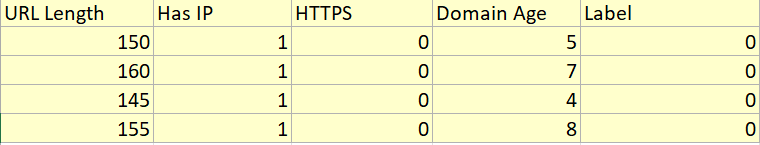

In [98]:
poisoned_data = pd.DataFrame({ "URL Length": [150, 155, 160, 148, 165, 145, 158, 170, 152, 162],
                              "Has_IP": [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
                              "HTTPS": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                              "Domain_Age": [5, 4, 6, 7, 3, 5, 4, 2, 6, 3],
                              "is_malicious":[0, 0, 0, 0, 0, 0, 0, 0, 0, 0] })

In [99]:
data_poisoned = pd.concat([data, poisoned_data], ignore_index=True)

In [100]:
X = data_poisoned.drop("is_malicious", axis=1)
y = data_poisoned["is_malicious"]

**Retraining the Model (After Attack)**

In [101]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )

In [102]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [103]:
predictions = model.predict(X_test)

In [104]:
accuracy = accuracy_score(y_test, predictions) * 100
cm = confusion_matrix(y_test, predictions)

In [105]:
print(f"Accuracy After Attack: {accuracy:.2f}%\n")
print("Confusion Matrix:\n")
print("\tPredicted Legit\tPredicted Phishing")
print(f"Legit\t\t{cm[0][0]}\t\t{cm[0][1]}")
print(f"Phishing\t{cm[1][0]}\t\t{cm[1][1]}")

Accuracy After Attack: 75.00%

Confusion Matrix:

	Predicted Legit	Predicted Phishing
Legit		8		2
Phishing	1		1


As you can see after poisoning the dataset:

- Model accuracy drops
- False negatives increase
- Phishing websites are misclassified as legitimate
- Overall system trust is compromised